## Импорты

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import time
import pandas as pd
import tensorflow as tf
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

## Загрузка и предобработка данных MNIST

In [14]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print(f'Обучающая выборка: {X_train.shape}  (изображений: {X_train.shape[0]})')
print(f'Тестовая выборка:  {X_test.shape}  (изображений: {X_test.shape[0]})')
print(f'Размер одного изображения: {X_train.shape[1]}x{X_train.shape[2]} пикселей')
print(f'Диапазон значений пикселей: [{X_train.min()}, {X_train.max()}]')

Обучающая выборка: (60000, 28, 28)  (изображений: 60000)
Тестовая выборка:  (10000, 28, 28)  (изображений: 10000)
Размер одного изображения: 28x28 пикселей
Диапазон значений пикселей: [0, 255]


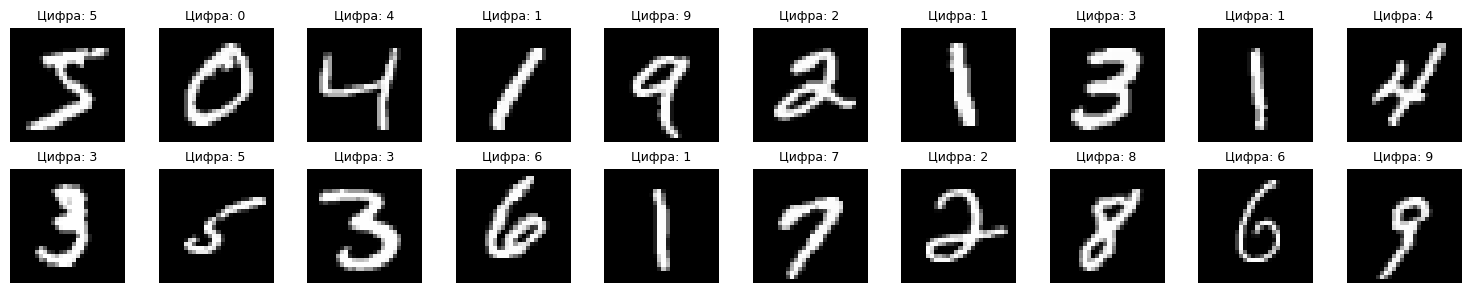

In [15]:
fig, axes = plt.subplots(2, 10, figsize=(15, 3))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i], cmap='gray')
    ax.set_title(f'Цифра: {y_train[i]}', fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [16]:
# Разворачиваем 2D-изображения (28x28) в одномерный вектор (784)
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat  = X_test.reshape(X_test.shape[0], -1)

# Нормализуем: переводим пиксели из [0, 255] в [0.0, 1.0]
X_train_flat = X_train_flat.astype('float32') / 255.0
X_test_flat  = X_test_flat.astype('float32') / 255.0

# One-hot кодирование меток (10 классов: цифры 0–9)
y_train_ohe = to_categorical(y_train, num_classes=10)
y_test_ohe  = to_categorical(y_test, num_classes=10)

## Создание и обучение персептронов

Создадим **4 модели** с разной архитектурой:

| Модель | Слои | Нейронов |
|--------|------|----------|
| M1 | 2 слоя | 64 → 10 |
| M2 | 2 слоя | 256 → 10 |
| M3 | 3 слоя | 128 → 64 → 10 |
| M4 | 4 слоя | 256 → 128 → 64 → 10 |

In [17]:
def build_model(layer_sizes, name='model', activation='relu'):

    # Строит персептрон 
    
    model = models.Sequential(name=name)
    
    # Входной слой — принимает вектор из 784 чисел
    model.add(layers.Input(shape=(784,)))
    
    # Скрытые слои
    for size in layer_sizes[:-1]:
        model.add(layers.Dense(size, activation=activation))
    
    # Выходной слой — 10 нейронов (по одному на каждую цифру)
    model.add(layers.Dense(layer_sizes[-1], activation='softmax'))
    
  
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


model_configs = [
    {'name': 'M1',   'layers': [64, 10]},
    {'name': 'M2',   'layers': [256, 10]},
    {'name': 'M3', 'layers': [128, 64, 10]},
    {'name': 'M4',   'layers': [256, 128, 64, 10]},
]

models_list = []
for cfg in model_configs:
    m = build_model(cfg['layers'], name=cfg['name'])
    models_list.append(m)
    print(f"\n{'='*50}")
    print(f"Модель: {cfg['name']}")
    m.summary()


Модель: M1


Model: "M1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_11 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,890 (198.79 KB)

 Trainable params: 50,890 (198.79 KB)

...

Model: "M4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,762 (948.29 KB)

 Trainable params: 242,762 (948.29 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
# Обучаем все модели 
histories = []
train_times = []

EPOCHS = 10
BATCH_SIZE = 128

for i, model in enumerate(models_list):
    name = model_configs[i]['name']
    print(f"\n{'='*50}")
    print(f"Обучение модели: {name}")
    print(f"{'='*50}")
    
    start = time.time()
    history = model.fit(
        X_train_flat, y_train_ohe,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=0.1,   # 10% обучающей выборки — для валидации
        verbose=1
    )
    elapsed = time.time() - start
    
    histories.append(history)
    train_times.append(elapsed)
    print(f"Время обучения: {elapsed:.1f} сек.")


Обучение модели: M1
Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8809 - loss: 0.4337 - val_accuracy: 0.9452 - val_loss: 0.2023
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9363 - loss: 0.2235 - val_accuracy: 0.9572 - val_loss: 0.1575
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9501 - loss: 0.1737 - val_accuracy: 0.9647 - val_loss: 0.1349
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9576 - loss: 0.1435 - val_accuracy: 0.9677 - val_loss: 0.1174
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9649 - loss: 0.1206 - val_accuracy: 0.9682 - val_loss: 0.1088
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9699 - loss: 0.1037 - val_accuracy: 0.9703 - val_loss: 0.1015
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9725 - loss: 0.0912 - val_accuracy: 0.9727 - val_loss: 0.0959
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9761 - loss: 0.08

##  Результат

In [19]:
print(f"{'Модель':<25} {'Потери (loss)':<18} {'Точность (acc)':<18} {'Время обучения'}")
print('-' * 75)

results = []
for i, model in enumerate(models_list):
    loss, acc = model.evaluate(X_test_flat, y_test_ohe, verbose=0)
    name = model_configs[i]['name']
    t = train_times[i]
    results.append({'name': name, 'loss': loss, 'acc': acc, 'time': t})
    print(f"{name:<25} {loss:<18.4f} {acc:<18.4f} {t:.1f} сек.")

Модель                    Потери (loss)      Точность (acc)     Время обучения
---------------------------------------------------------------------------
M1                        0.1003             0.9701             6.6 сек.
M2                        0.0658             0.9804             10.6 сек.
M3                        0.0742             0.9784             8.9 сек.
M4                        0.0804             0.9797             15.4 сек.


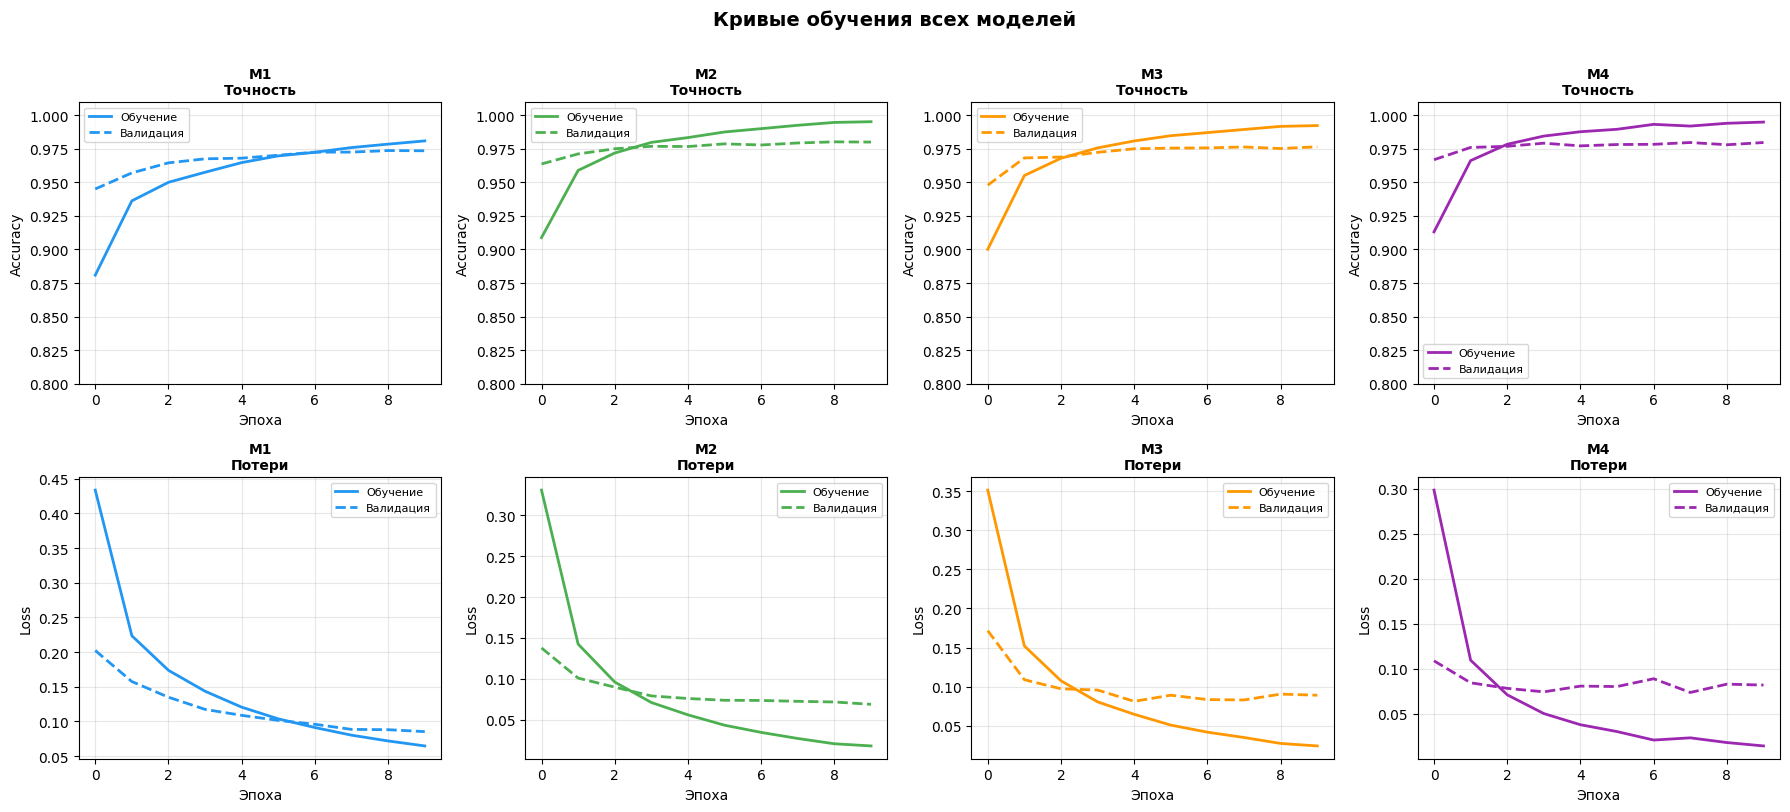

In [20]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

for i, (history, cfg) in enumerate(zip(histories, model_configs)):
    name = cfg['name']
    c = colors[i]
    
    ax_acc = axes[0, i]
    ax_acc.plot(history.history['accuracy'],     color=c,     label='Обучение', linewidth=2)
    ax_acc.plot(history.history['val_accuracy'], color=c, linestyle='--', label='Валидация', linewidth=2)
    ax_acc.set_title(f'{name}\nТочность', fontsize=10, fontweight='bold')
    ax_acc.set_xlabel('Эпоха')
    ax_acc.set_ylabel('Accuracy')
    ax_acc.legend(fontsize=8)
    ax_acc.set_ylim([0.8, 1.01])
    ax_acc.grid(True, alpha=0.3)
    
    ax_loss = axes[1, i]
    ax_loss.plot(history.history['loss'],     color=c,     label='Обучение', linewidth=2)
    ax_loss.plot(history.history['val_loss'], color=c, linestyle='--', label='Валидация', linewidth=2)
    ax_loss.set_title(f'{name}\nПотери', fontsize=10, fontweight='bold')
    ax_loss.set_xlabel('Эпоха')
    ax_loss.set_ylabel('Loss')
    ax_loss.legend(fontsize=8)
    ax_loss.grid(True, alpha=0.3)

plt.suptitle('Кривые обучения всех моделей', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

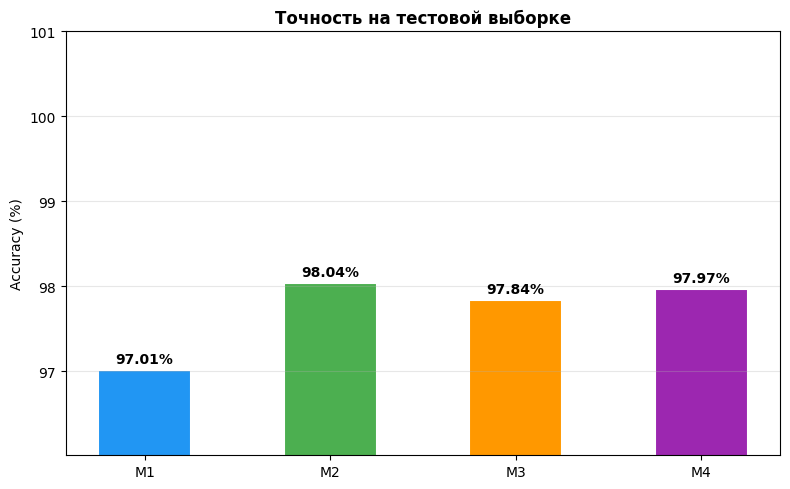

In [21]:
names = [r['name'].replace('_', '\n') for r in results]
accs  = [r['acc'] * 100 for r in results]

fig, ax = plt.subplots(figsize=(8, 5)) 

bars = ax.bar(names, accs, color=colors, width=0.5, edgecolor='white', linewidth=1.5)

for bar, val in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{val:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=10)

ax.set_title('Точность на тестовой выборке', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy (%)')
ax.set_ylim([min(accs) - 1, 101])
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Лучшая модель: M2  (точность: 98.04%)


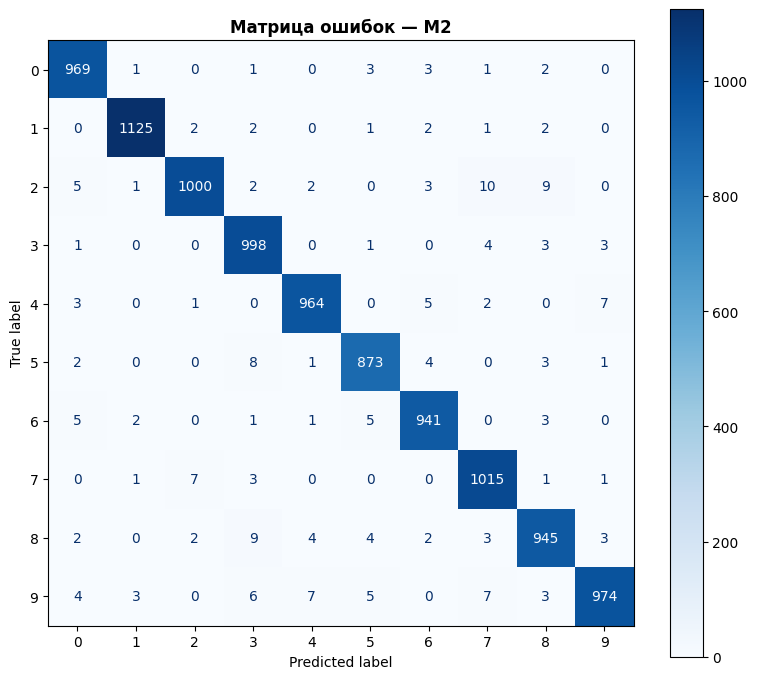

In [22]:
# Матрица ошибок для лучшей модели
best_idx   = np.argmax([r['acc'] for r in results])
best_model = models_list[best_idx]
best_name  = results[best_idx]['name']

print(f'Лучшая модель: {best_name}  (точность: {results[best_idx]["acc"]*100:.2f}%)')

y_pred_prob = best_model.predict(X_test_flat, verbose=0)
y_pred      = np.argmax(y_pred_prob, axis=1)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(10))

fig, ax = plt.subplots(figsize=(8, 7))
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title(f'Матрица ошибок — {best_name}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

Всего ошибочных предсказаний: 196 из 10000


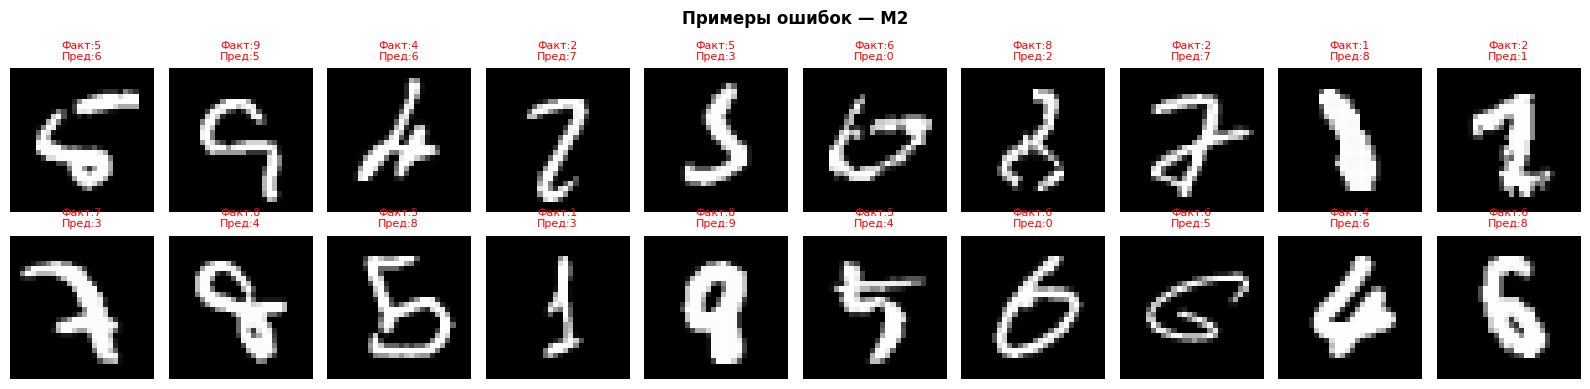

In [23]:
# Примеры неправильно классифицированных изображений
wrong_idx = np.where(y_pred != y_test)[0]
print(f'Всего ошибочных предсказаний: {len(wrong_idx)} из {len(y_test)}')

fig, axes = plt.subplots(2, 10, figsize=(16, 4))
for ax, idx in zip(axes.flat, wrong_idx[:20]):
    ax.imshow(X_test[idx], cmap='gray')
    ax.set_title(f'Факт:{y_test[idx]}\nПред:{y_pred[idx]}',
                 fontsize=8, color='red')
    ax.axis('off')
plt.suptitle(f'Примеры ошибок — {best_name}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [24]:
summary = []
for i, (model, cfg, r) in enumerate(zip(models_list, model_configs, results)):
    total_params = model.count_params()
    final_val_acc = histories[i].history['val_accuracy'][-1]
    summary.append({
        'Модель':             cfg['name'],
        'Слои':               len(cfg['layers']) - 1,
        'Архитектура':        ' → '.join(map(str, cfg['layers'])),
        'Параметров':         total_params,
        'Val Accuracy (last)': f"{final_val_acc*100:.2f}%",
        'Test Accuracy':       f"{r['acc']*100:.2f}%",
        'Test Loss':           f"{r['loss']:.4f}",
        'Время (сек)':         f"{r['time']:.1f}",
    })

df = pd.DataFrame(summary)
display(df.set_index('Модель'))

,Слои,Архитектура,Параметров,Val Accuracy (last),Test Accuracy,Test Loss,Время (сек)
Модель,,,,,,,
M1,1,64 → 10,50890,97.37%,97.01%,0.1003,6.6
M2,1,256 → 10,203530,98.02%,98.04%,0.0658,10.6
M3,2,128 → 64 → 10,109386,97.67%,97.84%,0.0742,8.9
M4,3,256 → 128 → 64 → 10,242762,97.98%,97.97%,0.0804,15.4
